# 📈 02 — Analisi Quantitativa: Trend Temporali, Finanziari e Settoriali

Questo notebook approfondisce l'analisi **quantitativa** degli aiuti di stato italiani classificati AI/NON_AI.

**Obiettivi:**
1. Trend temporali della proporzione AI
2. Evoluzione degli importi finanziari AI
3. Concentrazione finanziaria (Curva di Lorenz, Indice di Gini)
4. Analisi settoriale (codici ATECO)
5. Analisi regionale quantitativa (heatmap)
6. Tipo di beneficiario (PMI vs Grandi Imprese)

## 1. Setup e Caricamento Dati

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='deep', font_scale=1.1)
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 100

DATA_DIR = Path('../data')
YEARS = list(range(2014, 2026))

COLS_TO_LOAD = [
    'TITOLO_MISURA', 'DES_TIPO_MISURA',
    'DATA_CONCESSIONE', 'DENOMINAZIONE_BENEFICIARIO',
    'DES_TIPO_BENEFICIARIO', 'REGIONE_BENEFICIARIO',
    'IMPORTO_NOMINALE_TOTALE', 'ELEMENTO_DI_AIUTO_TOTALE',
    'SETTORI_ATTIVITA', 'CLASSIFICAZIONE', 'CLASSIFICAZIONE_CONFIDENZA'
]

print('Setup completato ✓')

Setup completato ✓


In [2]:
# Caricamento dati
frames = []
for year in YEARS:
    filepath = DATA_DIR / f'classified_aiuti_{year}.csv'
    if filepath.exists():
        print(f'Caricamento {year}...', end=' ')
        chunks = []
        for chunk in pd.read_csv(filepath, usecols=COLS_TO_LOAD, chunksize=100_000, low_memory=False):
            chunks.append(chunk)
        df_year = pd.concat(chunks, ignore_index=True)
        df_year['ANNO'] = year
        print(f'{len(df_year):>12,} righe')
        frames.append(df_year)

df = pd.concat(frames, ignore_index=True)
del frames

# Conversioni
df['IMPORTO_NOMINALE_TOTALE'] = pd.to_numeric(df['IMPORTO_NOMINALE_TOTALE'], errors='coerce')
df['ELEMENTO_DI_AIUTO_TOTALE'] = pd.to_numeric(df['ELEMENTO_DI_AIUTO_TOTALE'], errors='coerce')

# Estrai la sezione ATECO (prima lettera del codice attività)
df['SETTORI_ATTIVITA'] = df['SETTORI_ATTIVITA'].astype(str).str.split('|')
df = df.explode('SETTORI_ATTIVITA')
df['REGIONE_BENEFICIARIO'] = df['REGIONE_BENEFICIARIO'].astype(str).str.split('|')
df = df.explode('REGIONE_BENEFICIARIO')

df['SETTORE_MACRO'] = df['SETTORI_ATTIVITA'].astype(str).str[0].str.upper()

print(f'\n✅ Totale: {len(df):,} righe caricate')

Caricamento 2014...       15,448 righe
Caricamento 2015...        2,299 righe
Caricamento 2016...        8,378 righe
Caricamento 2017...      214,546 righe
Caricamento 2018...      685,622 righe
Caricamento 2019...      514,265 righe
Caricamento 2020...    2,669,916 righe
Caricamento 2021...    3,221,074 righe
Caricamento 2022...    2,062,853 righe
Caricamento 2023...    6,478,711 righe
Caricamento 2024...    6,022,284 righe
Caricamento 2025...    2,061,972 righe

✅ Totale: 23,962,273 righe caricate


## 2. Trend Temporali della Proporzione AI

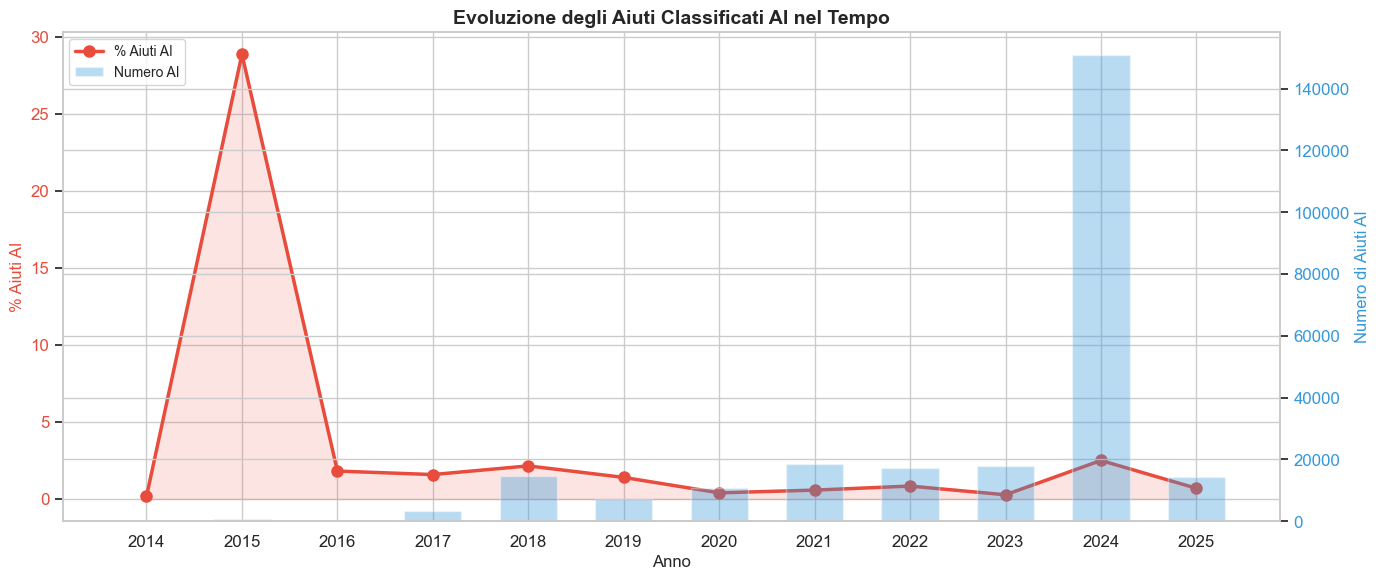

,ANNO,pct_ai,num_ai
0,2014,0.1683,26
1,2015,28.8696,664
2,2016,1.8143,152
3,2017,1.5865,3404
4,2018,2.1493,14737
5,2019,1.4010,7205
6,2020,0.4003,10689
7,2021,0.5772,18593
8,2022,0.8396,17320
9,2023,0.2747,17796


In [3]:
# Calcola proporzione AI per anno
trend = df.groupby('ANNO')['CLASSIFICAZIONE'].apply(
    lambda x: (x == 'AI').sum() / len(x) * 100
).reset_index(name='pct_ai')

# Numero assoluto di AI per anno
ai_counts = df[df['CLASSIFICAZIONE'] == 'AI'].groupby('ANNO').size().reset_index(name='num_ai')
trend = trend.merge(ai_counts, on='ANNO', how='left').fillna(0)

fig, ax1 = plt.subplots(figsize=(14, 6))

color1 = '#e74c3c'
ax1.plot(trend['ANNO'], trend['pct_ai'], marker='o', linewidth=2.5, color=color1, 
         markersize=8, label='% Aiuti AI', zorder=5)
ax1.fill_between(trend['ANNO'], trend['pct_ai'], alpha=0.15, color=color1)
ax1.set_xlabel('Anno', fontsize=12)
ax1.set_ylabel('% Aiuti AI', color=color1, fontsize=12)
ax1.tick_params(axis='y', labelcolor=color1)
ax1.set_xticks(YEARS)

ax2 = ax1.twinx()
color2 = '#3498db'
ax2.bar(trend['ANNO'], trend['num_ai'], alpha=0.35, color=color2, label='Numero AI', width=0.6)
ax2.set_ylabel('Numero di Aiuti AI', color=color2, fontsize=12)
ax2.tick_params(axis='y', labelcolor=color2)

# Legenda combinata
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=10)

plt.title('Evoluzione degli Aiuti Classificati AI nel Tempo', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Tabella
trend.round(4)

## 3. Evoluzione degli Importi Finanziari AI

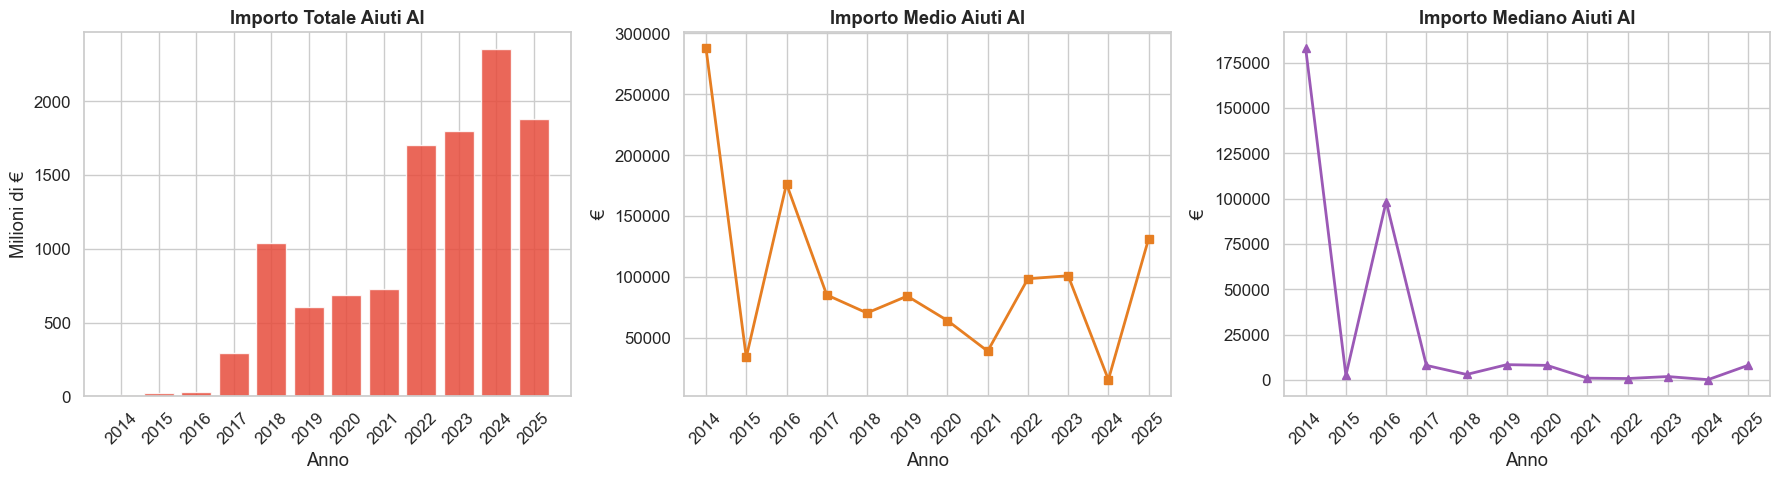

In [4]:
# Importi per anno — solo AI
df_ai = df[df['CLASSIFICAZIONE'] == 'AI'].copy()

fin_ai = df_ai.groupby('ANNO')['IMPORTO_NOMINALE_TOTALE'].agg(
    ['sum', 'mean', 'median', 'count']
).rename(columns={'sum': 'totale', 'mean': 'media', 'median': 'mediana', 'count': 'n'})

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Importo totale AI
axes[0].bar(fin_ai.index, fin_ai['totale'] / 1e6, color='#e74c3c', edgecolor='white', alpha=0.85)
axes[0].set_title('Importo Totale Aiuti AI', fontweight='bold')
axes[0].set_xlabel('Anno')
axes[0].set_ylabel('Milioni di €')
axes[0].set_xticks(YEARS)
axes[0].tick_params(axis='x', rotation=45)

# Importo medio AI
axes[1].plot(fin_ai.index, fin_ai['media'], marker='s', linewidth=2, color='#e67e22')
axes[1].set_title('Importo Medio Aiuti AI', fontweight='bold')
axes[1].set_xlabel('Anno')
axes[1].set_ylabel('€')
axes[1].set_xticks(YEARS)
axes[1].tick_params(axis='x', rotation=45)

# Importo mediano AI
axes[2].plot(fin_ai.index, fin_ai['mediana'], marker='^', linewidth=2, color='#9b59b6')
axes[2].set_title('Importo Mediano Aiuti AI', fontweight='bold')
axes[2].set_xlabel('Anno')
axes[2].set_ylabel('€')
axes[2].set_xticks(YEARS)
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

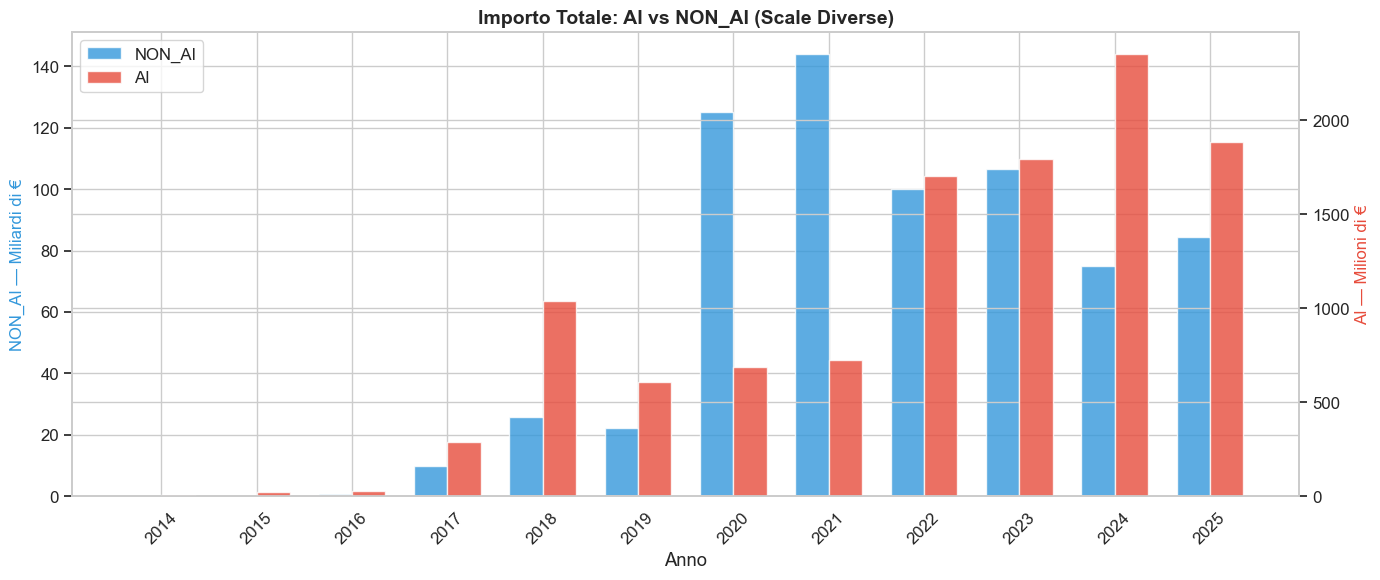

In [5]:
# Confronto importo totale AI vs NON_AI su doppio asse (scala diversa)
fin_both = df.groupby(['ANNO', 'CLASSIFICAZIONE'])['IMPORTO_NOMINALE_TOTALE'].sum().unstack(fill_value=0)

fig, ax1 = plt.subplots(figsize=(14, 6))

x = np.arange(len(YEARS))
width = 0.35

if 'NON_AI' in fin_both.columns:
    ax1.bar(x - width/2, fin_both['NON_AI'] / 1e9, width, label='NON_AI', color='#3498db', alpha=0.8)
    ax1.set_ylabel('NON_AI — Miliardi di €', color='#3498db', fontsize=12)

ax2 = ax1.twinx()
if 'AI' in fin_both.columns:
    ax2.bar(x + width/2, fin_both['AI'] / 1e6, width, label='AI', color='#e74c3c', alpha=0.8)
    ax2.set_ylabel('AI — Milioni di €', color='#e74c3c', fontsize=12)

ax1.set_xlabel('Anno')
ax1.set_xticks(x)
ax1.set_xticklabels(YEARS, rotation=45)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.title('Importo Totale: AI vs NON_AI (Scale Diverse)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Concentrazione Finanziaria — Curva di Lorenz e Gini

In [6]:
def gini_coefficient(values):
    """Calcola il coefficiente di Gini di un array di valori."""
    values = np.sort(values[values > 0])  # escludi zeri
    n = len(values)
    if n == 0:
        return 0
    index = np.arange(1, n + 1)
    return (2 * np.sum(index * values) - (n + 1) * np.sum(values)) / (n * np.sum(values))


def lorenz_curve(values):
    """Restituisce le coordinate per la curva di Lorenz."""
    values = np.sort(values[values > 0])
    cum_values = np.cumsum(values) / np.sum(values)
    cum_pop = np.arange(1, len(values) + 1) / len(values)
    return np.concatenate([[0], cum_pop]), np.concatenate([[0], cum_values])

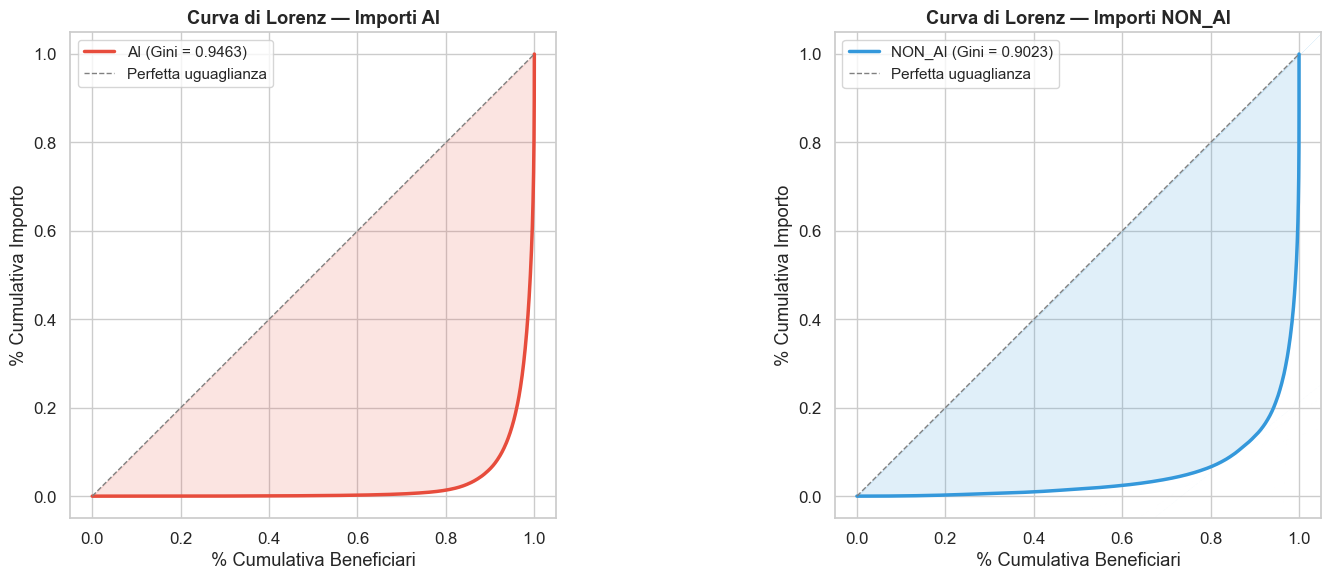

Indice di Gini — AI:     0.9463
Indice di Gini — NON_AI: 0.9023


In [7]:
# Curva di Lorenz per importi AI
ai_importi = df_ai['IMPORTO_NOMINALE_TOTALE'].dropna().values

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# AI
x_ai, y_ai = lorenz_curve(ai_importi)
gini_ai = gini_coefficient(ai_importi)
axes[0].plot(x_ai, y_ai, linewidth=2.5, color='#e74c3c', label=f'AI (Gini = {gini_ai:.4f})')
axes[0].plot([0, 1], [0, 1], '--', color='gray', linewidth=1, label='Perfetta uguaglianza')
axes[0].fill_between(x_ai, y_ai, x_ai, alpha=0.15, color='#e74c3c')
axes[0].set_title('Curva di Lorenz — Importi AI', fontweight='bold')
axes[0].set_xlabel('% Cumulativa Beneficiari')
axes[0].set_ylabel('% Cumulativa Importo')
axes[0].legend(fontsize=11)
axes[0].set_aspect('equal')

# NON_AI
nonai_importi = df[df['CLASSIFICAZIONE'] == 'NON_AI']['IMPORTO_NOMINALE_TOTALE'].dropna().values
x_na, y_na = lorenz_curve(nonai_importi)
gini_na = gini_coefficient(nonai_importi)
axes[1].plot(x_na, y_na, linewidth=2.5, color='#3498db', label=f'NON_AI (Gini = {gini_na:.4f})')
axes[1].plot([0, 1], [0, 1], '--', color='gray', linewidth=1, label='Perfetta uguaglianza')
axes[1].fill_between(x_na, y_na, x_na, alpha=0.15, color='#3498db')
axes[1].set_title('Curva di Lorenz — Importi NON_AI', fontweight='bold')
axes[1].set_xlabel('% Cumulativa Beneficiari')
axes[1].set_ylabel('% Cumulativa Importo')
axes[1].legend(fontsize=11)
axes[1].set_aspect('equal')

plt.tight_layout()
plt.show()

print(f'Indice di Gini — AI:     {gini_ai:.4f}')
print(f'Indice di Gini — NON_AI: {gini_na:.4f}')

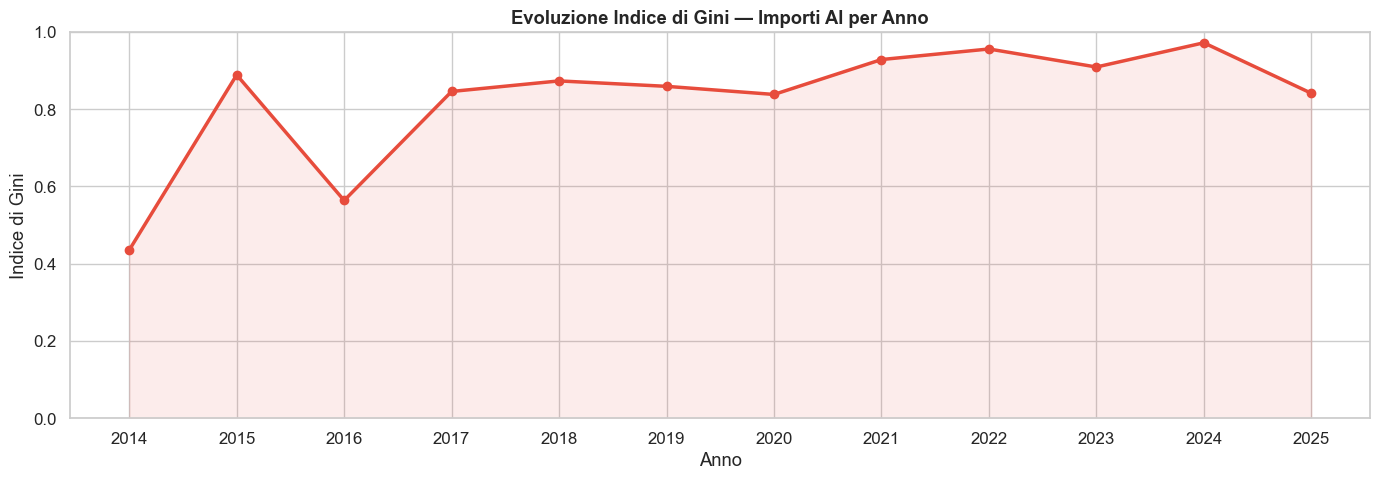

In [8]:
# Gini per anno — AI
gini_per_anno = df_ai.groupby('ANNO')['IMPORTO_NOMINALE_TOTALE'].apply(
    lambda x: gini_coefficient(x.dropna().values)
).reset_index(name='gini')

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(gini_per_anno['ANNO'], gini_per_anno['gini'], marker='o', linewidth=2.5, color='#e74c3c')
ax.fill_between(gini_per_anno['ANNO'], gini_per_anno['gini'], alpha=0.1, color='#e74c3c')
ax.set_title('Evoluzione Indice di Gini — Importi AI per Anno', fontweight='bold')
ax.set_xlabel('Anno')
ax.set_ylabel('Indice di Gini')
ax.set_xticks(YEARS)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

## 5. Analisi Settoriale (Codici ATECO)

In [9]:
# Mappatura sezioni ATECO
ATECO_SEZIONI = {
    'A': 'Agricoltura', 'B': 'Estrazione', 'C': 'Manifatturiero',
    'D': 'Energia', 'E': 'Acqua/Rifiuti', 'F': 'Costruzioni',
    'G': 'Commercio', 'H': 'Trasporti', 'I': 'Alloggio/Ristorazione',
    'J': 'Informazione/Comunicazione', 'K': 'Finanza/Assicurazioni',
    'L': 'Immobiliare', 'M': 'Attività professionali', 'N': 'Noleggio/Servizi',
    'O': 'PA', 'P': 'Istruzione', 'Q': 'Sanità', 'R': 'Arte/Intrattenimento',
    'S': 'Altri servizi', 'T': 'Famiglie', 'U': 'Organizzazioni extra-territoriali'
}

df['SETTORE_NOME'] = df['SETTORE_MACRO'].map(ATECO_SEZIONI).fillna('Altro')

In [10]:
# Distribuzione settoriale AI vs NON_AI
sett_class = df.groupby(['SETTORE_NOME', 'CLASSIFICAZIONE']).size().unstack(fill_value=0)
if 'AI' in sett_class.columns:
    sett_class['% AI'] = (sett_class['AI'] / sett_class.sum(axis=1) * 100).round(3)
    sett_class = sett_class.sort_values('AI', ascending=False)

sett_class

CLASSIFICAZIONE,AI,NON_AI,UNKNOWN,% AI
SETTORE_NOME,,,,
Altro,155933,5651115,1,2.685
Commercio,19336,4335469,1,0.444
Manifatturiero,18858,2647475,1,0.707
Alloggio/Ristorazione,12475,2841163,0,0.437
Attività professionali,11645,1137267,0,1.014
Informazione/Comunicazione,7366,450558,1,1.609
Altri servizi,6810,933490,0,0.724
Costruzioni,5539,2003373,0,0.276
Istruzione,3453,209214,0,1.624


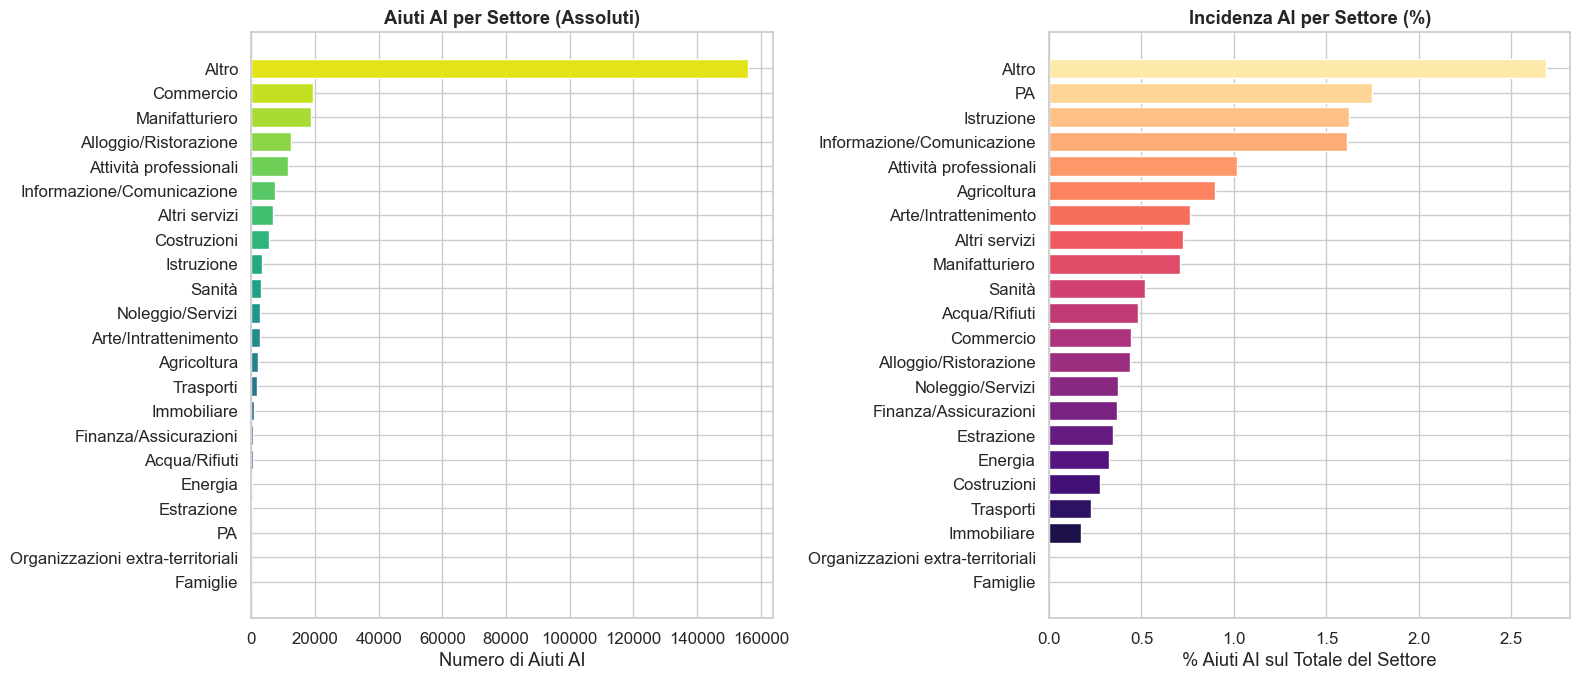

In [11]:
# Grafico: Top settori per incidenza AI
if 'AI' in sett_class.columns:
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    
    # Numero assoluto per settore
    top_sett = sett_class['AI'].sort_values(ascending=True)
    colors = sns.color_palette('viridis', len(top_sett))
    axes[0].barh(top_sett.index, top_sett.values, color=colors, edgecolor='white')
    axes[0].set_xlabel('Numero di Aiuti AI')
    axes[0].set_title('Aiuti AI per Settore (Assoluti)', fontweight='bold')
    
    # % AI per settore
    pct_sett = sett_class['% AI'].sort_values(ascending=True)
    colors2 = sns.color_palette('magma', len(pct_sett))
    axes[1].barh(pct_sett.index, pct_sett.values, color=colors2, edgecolor='white')
    axes[1].set_xlabel('% Aiuti AI sul Totale del Settore')
    axes[1].set_title('Incidenza AI per Settore (%)', fontweight='bold')
    
    plt.tight_layout()
    plt.show()

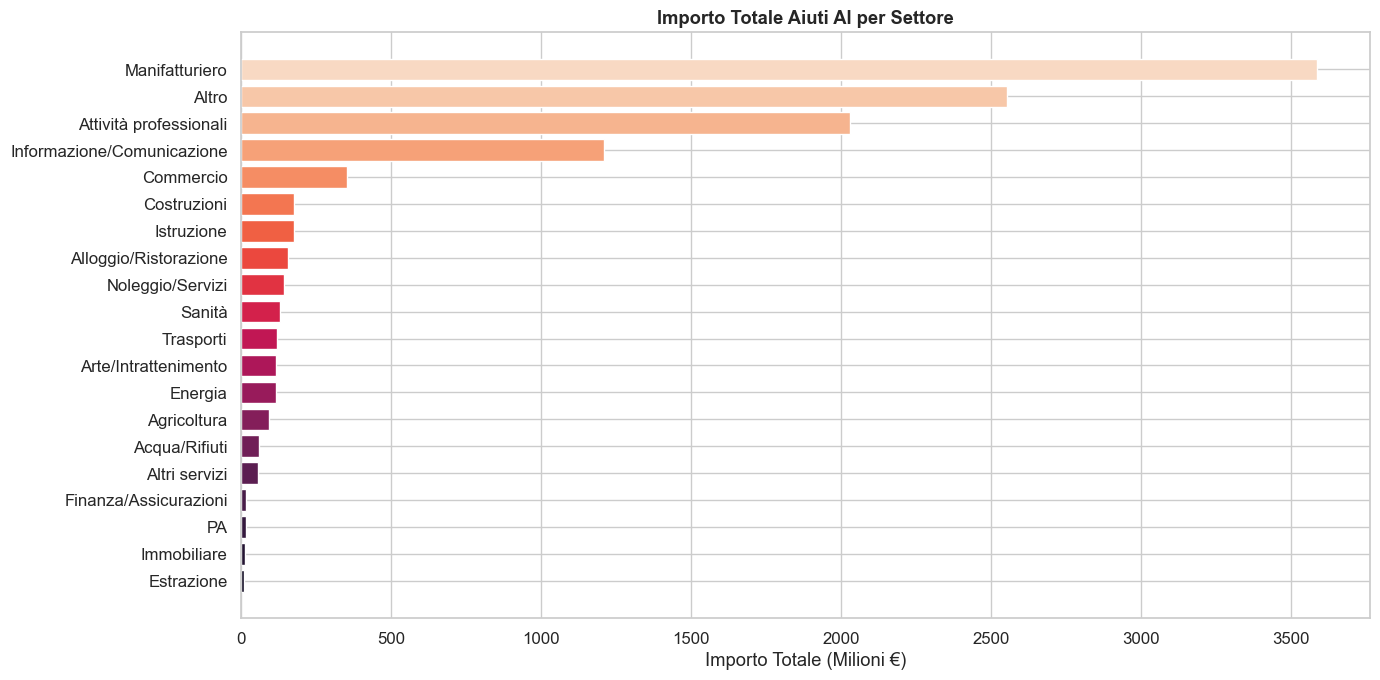

In [12]:
# Importi medi AI per settore
if len(df_ai) > 0:
    df_ai['SETTORE_NOME'] = df_ai['SETTORE_MACRO'].map(ATECO_SEZIONI).fillna('Altro')
    
    importi_settore = df_ai.groupby('SETTORE_NOME')['IMPORTO_NOMINALE_TOTALE'].agg(
        ['mean', 'median', 'sum', 'count']
    ).sort_values('sum', ascending=False)
    
    fig, ax = plt.subplots(figsize=(14, 7))
    importi_plot = importi_settore.sort_values('sum', ascending=True)
    ax.barh(importi_plot.index, importi_plot['sum'] / 1e6,
            color=sns.color_palette('rocket', len(importi_plot)), edgecolor='white')
    ax.set_xlabel('Importo Totale (Milioni €)')
    ax.set_title('Importo Totale Aiuti AI per Settore', fontweight='bold')
    plt.tight_layout()
    plt.show()

## 6. Analisi Regionale Quantitativa

In [13]:
# Heatmap: Regione × Anno — numero aiuti AI
if len(df_ai) > 0:
    heatmap_data = df_ai.groupby(['REGIONE_BENEFICIARIO', 'ANNO']).size().unstack(fill_value=0)
    
    fig, ax = plt.subplots(figsize=(16, 10))
    sns.heatmap(heatmap_data, annot=True, fmt='d', cmap='YlOrRd', linewidths=0.5,
                ax=ax, cbar_kws={'label': 'Numero Aiuti AI'})
    ax.set_title('Heatmap: Numero Aiuti AI per Regione e Anno', fontsize=14, fontweight='bold')
    ax.set_xlabel('Anno')
    ax.set_ylabel('Regione')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
    plt.tight_layout()
    plt.show()

IndentationError: unexpected indent (2617412809.py, line 13)

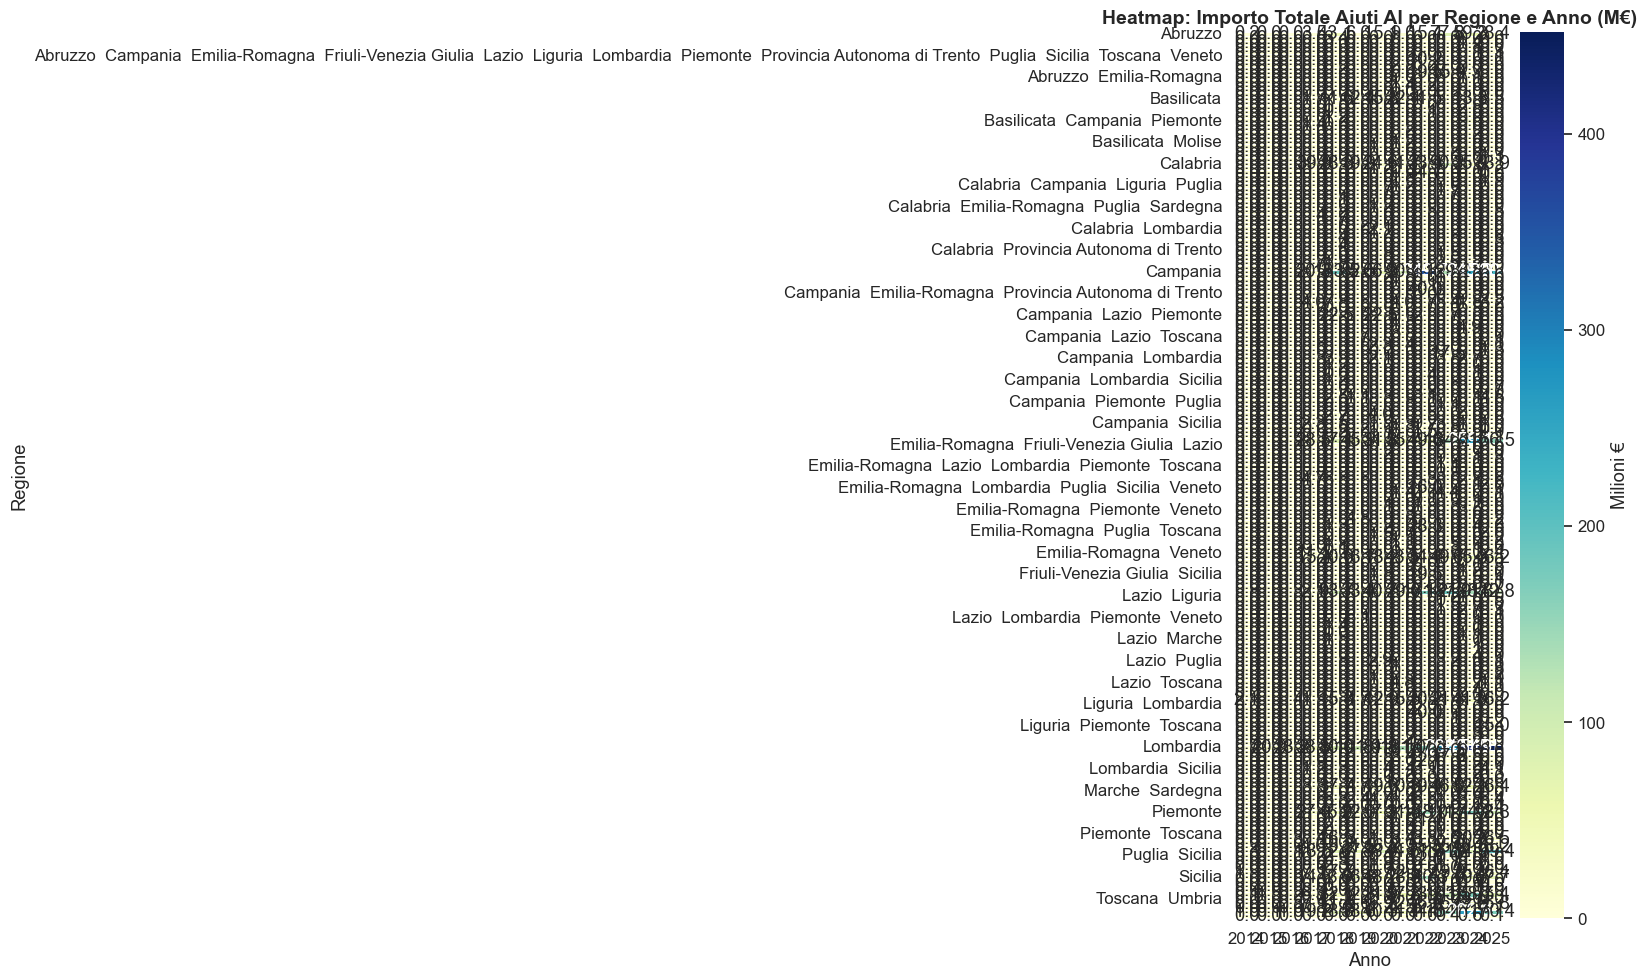

In [ ]:
# Heatmap: Regione × Anno — importo totale AI (milioni €)
if len(df_ai) > 0:
    heatmap_importi = (df_ai.groupby(['REGIONE_BENEFICIARIO', 'ANNO'])['IMPORTO_NOMINALE_TOTALE']
                       .sum().unstack(fill_value=0) / 1e6)
    
    fig, ax = plt.subplots(figsize=(16, 10))
    sns.heatmap(heatmap_importi, annot=True, fmt='.1f', cmap='YlGnBu', linewidths=0.5,
                ax=ax, cbar_kws={'label': 'Milioni €'})
    ax.set_title('Heatmap: Importo Totale Aiuti AI per Regione e Anno (M€)', fontsize=14, fontweight='bold')
    ax.set_xlabel('Anno')
    ax.set_ylabel('Regione')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
    plt.tight_layout()
    plt.show()

## 7. Tipo di Beneficiario

In [ ]:
# Distribuzione per tipo di beneficiario
tipo_class = df.groupby(['DES_TIPO_BENEFICIARIO', 'CLASSIFICAZIONE']).size().unstack(fill_value=0)
if 'AI' in tipo_class.columns:
    tipo_class['% AI'] = (tipo_class['AI'] / tipo_class.sum(axis=1) * 100).round(3)
    tipo_class = tipo_class.sort_values('AI', ascending=False)

tipo_class

CLASSIFICAZIONE,AI,NON_AI,UNKNOWN,% AI
DES_TIPO_BENEFICIARIO,,,,
PMI,147320,22255457,4,0.658
Non classificata,101569,1274350,0,7.382
Grande impresa,4828,160450,0,2.921
-,1538,11852,0,11.486


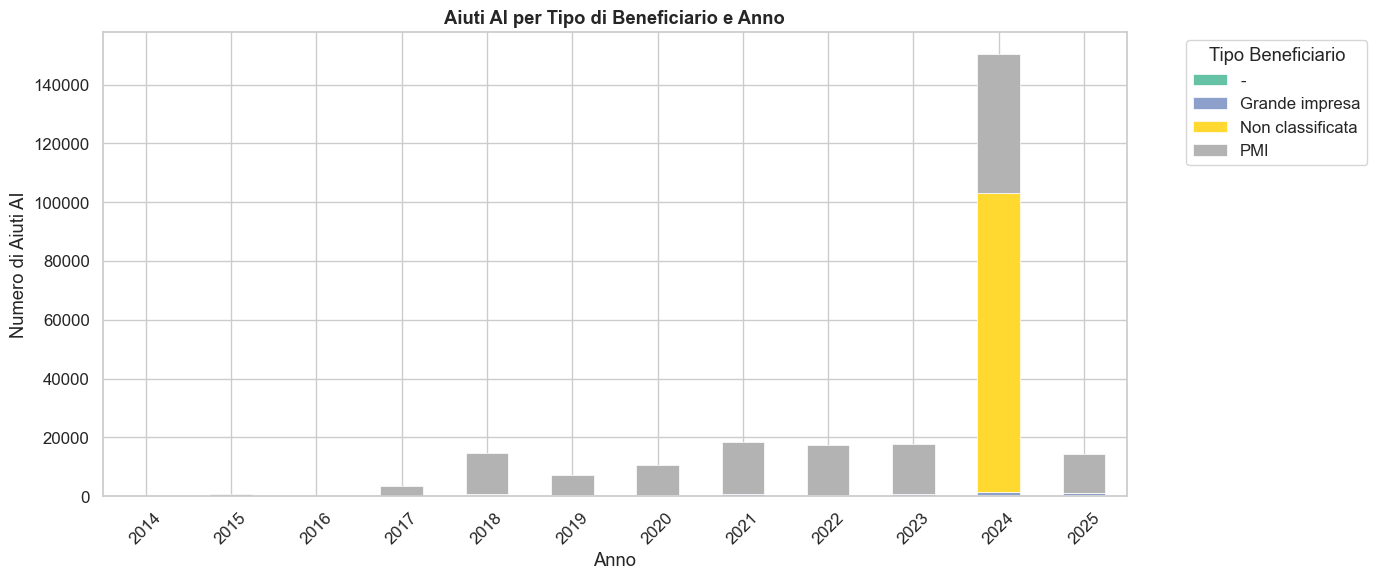

In [ ]:
# Grafico tipo beneficiario per AI
if len(df_ai) > 0:
    tipo_ai_year = (df_ai.groupby(['ANNO', 'DES_TIPO_BENEFICIARIO']).size()
                    .unstack(fill_value=0))
    
    fig, ax = plt.subplots(figsize=(14, 6))
    tipo_ai_year.plot(kind='bar', stacked=True, ax=ax, 
                      colormap='Set2', edgecolor='white', linewidth=0.5)
    ax.set_title('Aiuti AI per Tipo di Beneficiario e Anno', fontweight='bold')
    ax.set_xlabel('Anno')
    ax.set_ylabel('Numero di Aiuti AI')
    ax.legend(title='Tipo Beneficiario', bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()

In [ ]:
# Importo medio per tipo di beneficiario — AI
if len(df_ai) > 0:
    importo_tipo = df_ai.groupby('DES_TIPO_BENEFICIARIO')['IMPORTO_NOMINALE_TOTALE'].agg(
        ['mean', 'median', 'count', 'sum']
    ).sort_values('sum', ascending=False)
    
    importo_tipo_fmt = importo_tipo.copy()
    for col in ['mean', 'median', 'sum']:
        importo_tipo_fmt[col] = importo_tipo_fmt[col].apply(lambda x: f'€ {x:,.2f}')
    importo_tipo_fmt

## 8. Riepilogo

In questo notebook abbiamo approfondito:
- Il **trend temporale** degli aiuti AI (crescita/decrescita)
- L'**evoluzione finanziaria** degli importi AI
- La **concentrazione** degli importi (Gini e Lorenz)
- La distribuzione per **settore ATECO** e **regione**
- Il profilo dei **beneficiari** (PMI vs grandi imprese)

Per analisi qualitative e testuali → **03_analisi_qualitativa.ipynb**